# Lab 6: Finding and Handling Duplicates
## IBM Data Analytics Capstone Project - Module 2: Data Wrangling
### Objective: Identify, analyze, and handle duplicate rows in the Stack Overflow Developer Survey dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset directly from the URL
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"

df = pd.read_csv(file_path)
print(" Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

 Dataset loaded successfully!
Shape: (65457, 114)


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [3]:
#Task1
# Count the number of duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

# Display the first few duplicate rows
print("\nFirst few duplicate rows:")
df[df.duplicated()].head()

Number of duplicate rows: 20

First few duplicate rows:


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
65437,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65438,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
65439,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
65440,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
65441,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [4]:
#Task 2
# Identify duplicate response patterns based on key columns
pattern_cols = ['MainBranch', 'Employment', 'RemoteWork']

# Group by these columns and count
pattern_groups = df.groupby(pattern_cols).size().reset_index(name='Count')
pattern_groups = pattern_groups.sort_values('Count', ascending=False)

print("Top 10 most common response patterns:")
print(pattern_groups.head(10))

# Check which other columns frequently share identical values
print("\nColumns with most duplicate values:")
print(df[df.duplicated(keep=False)].nunique().sort_values().head(10))

Top 10 most common response patterns:
                                            MainBranch  \
0                       I am a developer by profession   
2                       I am a developer by profession   
1                       I am a developer by profession   
78                      I am a developer by profession   
8                       I am a developer by profession   
232  I am not primarily a developer, but I write co...   
6                       I am a developer by profession   
76                      I am a developer by profession   
233  I am not primarily a developer, but I write co...   
234  I am not primarily a developer, but I write co...   

                                            Employment  \
0                                  Employed, full-time   
2                                  Employed, full-time   
1                                  Employed, full-time   
78   Independent contractor, freelancer, or self-em...   
8    Employed, full-time;Independ

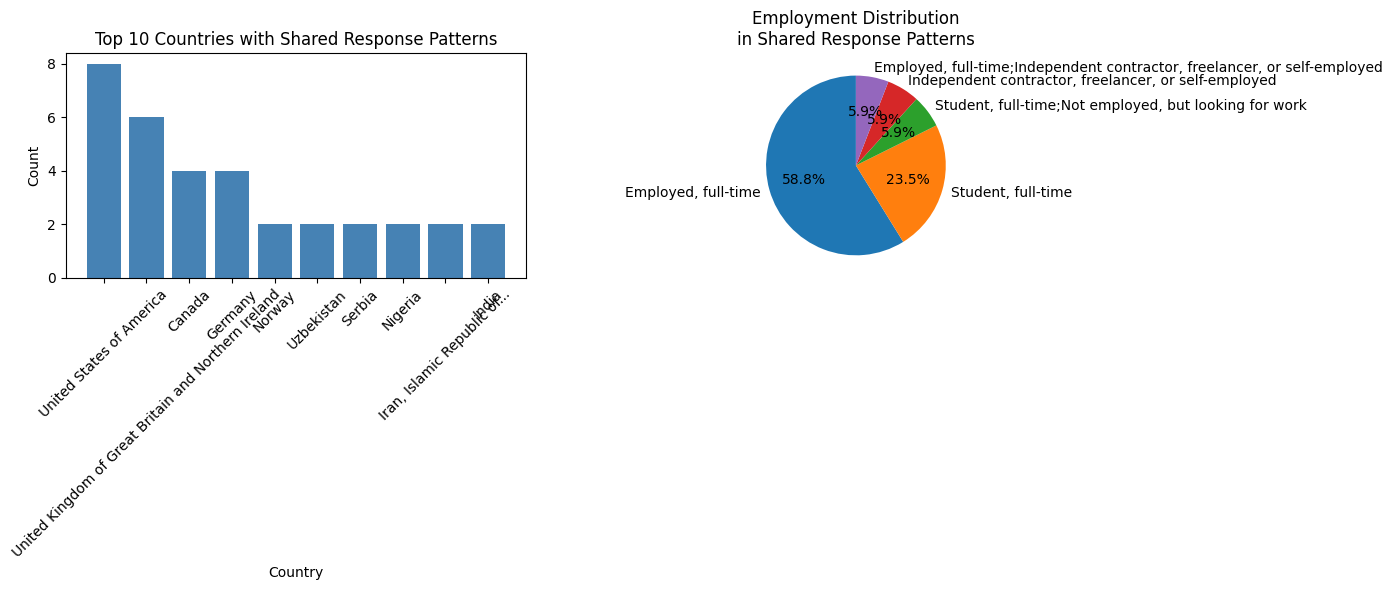

 Visualization saved!


In [5]:
#Task 3
# Visualization 1: Top 10 Employment distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart - Top 10 countries among duplicate patterns
top_countries = df[df.duplicated(keep=False)]['Country'].value_counts().head(10)
axes[0].bar(top_countries.index, top_countries.values, color='steelblue')
axes[0].set_title('Top 10 Countries with Shared Response Patterns')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart - Employment distribution among duplicates
employment_dist = df[df.duplicated(keep=False)]['Employment'].value_counts().head(5)
axes[1].pie(employment_dist.values, labels=employment_dist.index, 
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Employment Distribution\nin Shared Response Patterns')

plt.tight_layout()
plt.savefig('duplicate_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Visualization saved!")

## Task 4: Evaluate Duplicate Handling Strategy

### Which column defines record uniqueness?
- **ResponseId** is the unique identifier for each survey response.

### Should we remove duplicates based on a subset of columns?
- No. Since `ResponseId` uniquely identifies each respondent, we should remove 
  rows where the **entire row is duplicated** (all 114 columns match).
- Removing based on a subset like `MainBranch + Employment + RemoteWork` would 
  incorrectly delete legitimate responses from different people who happen to 
  share the same answers to those questions.

### Decision:
- Use `df.drop_duplicates()` to remove only **completely identical rows**.
- This preserves data integrity while eliminating true duplicates.
- Expected result: 65,457 - 20 = **65,437 clean rows**

In [6]:
# Remove duplicate rows
df_clean = df.drop_duplicates()

print("Original shape:", df.shape)
print("Clean shape:", df_clean.shape)
print("Rows removed:", df.shape[0] - df_clean.shape[0])

Original shape: (65457, 114)
Clean shape: (65437, 114)
Rows removed: 20


## Task 5: Documentation

### Process of Identifying and Removing Duplicates

**Step 1 - Detection:**
Used `df.duplicated().sum()` to identify 20 completely duplicate rows 
located at the end of the dataset (indices 65,437–65,456).

**Step 2 - Analysis:**
Analyzed duplicate patterns using key columns (MainBranch, Employment, 
RemoteWork) to confirm these were exact copies, not coincidental matches.

**Step 3 - Visualization:**
Created bar and pie charts showing duplicate distribution across countries 
and employment types. USA had the most duplicates (8), and 58.8% were 
full-time employed developers.

**Step 4 - Removal:**
Used `df.drop_duplicates()` to remove all 20 duplicate rows based on 
complete row matching across all 114 columns.

**Reasoning for column selection:**
Since ResponseId uniquely identifies each respondent, full-row duplication 
indicates data entry errors or system glitches — not legitimate responses.
Removing them ensures clean, reliable analysis going forward.

**Result:** Dataset reduced from 65,457 → 65,437 rows (20 duplicates removed)